<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **TAP queries to the <cite>asm.meteo_paranal**

Little illustration on how to query for relative humidity, pressure, temperature, wind speed and direction of a given night at Paranal.

<hr style="border:2px solid #0281c9">

## **Importing the necessary modules**

In [1]:
import astroquery # import astroquery
from astroquery.eso import Eso # import the ESO module from astroquery

print(f"astroquery version: {astroquery.__version__}") # check the version of astroquery

eso = Eso() # create an instance of the ESO class 

astroquery version: 0.4.11.dev10245


## **Query table column names**

The names of the fields of the ASM  do not coincide with the column names in the TAP table.

So let's check the column names, units, and descriptions of the "asm.meteo_paranal" table:

In [2]:
adql_query = """
            SELECT column_name, unit, description 
            FROM TAP_SCHEMA.columns 
            WHERE table_name='asm.meteo_paranal' 
            ORDER by 1
            """

table = eso.query_tap_service(adql_query)
table

column_name,unit,description
object,object,object
integration,s,Timebin [s] used for measurement of ambient data sample.
midpoint_date,,Midpoint (time) of the measurement.
presqnh,hPa,Air Pressure Normalised: 1 minute average pressure normalised to sea level [hPa]. (sci. param.)
presqnh_dev,hPa,Air Pressure Normalised RMS: 1 minute RMS pressure normalized to sea level [hPa]. (eng. param.)
presqnh_inst,hPa,Air Pressure Normalised instantaneous: Pressure normalized to sea level at the end of the averaging period [hPa]. (eng. param.)
presqnh_max,hPa,Air Pressure Normalised max: 1 minute maximum pressure normalized to sea level [hPa]. (eng. param.)
presqnh_min,hPa,Air Pressure Normalised min: 1 minute minimum pressure normalized to sea level [hPa]. (eng. param.)
press_0m,hPa,Air Pressure: Temporal (1 minute) mean of observatory site ambient baromeric air pressure measured at 0m above the VLT platform during measurement period [hPa]. (sci. param.)
press_0m_dev,hPa,Air Pressure RMS: 1 minute RMS surface pressure variation at 0m above the VLT platform [hPa]. (eng. param.)


In [3]:
for row in table:
    print(f"{row['column_name']:20} {row['unit']:10} {row['description']}")

integration          s          Timebin [s] used for measurement of ambient data sample.
midpoint_date                   Midpoint (time) of the measurement.
presqnh              hPa        Air Pressure Normalised: 1 minute average pressure normalised to sea level [hPa]. (sci. param.)
presqnh_dev          hPa        Air Pressure Normalised RMS: 1 minute RMS pressure normalized to sea level [hPa]. (eng. param.)
presqnh_inst         hPa        Air Pressure Normalised instantaneous: Pressure normalized to sea level at the end of the averaging period [hPa]. (eng. param.)
presqnh_max          hPa        Air Pressure Normalised max: 1 minute maximum pressure normalized to sea level [hPa]. (eng. param.)
presqnh_min          hPa        Air Pressure Normalised min: 1 minute  minimum pressure normalized to sea level [hPa]. (eng. param.)
press_0m             hPa        Air Pressure: Temporal (1 minute) mean of observatory site ambient baromeric air pressure measured at 0m above the VLT platform du

## **Query asm.metro_paranal table**

The following code queries for the average temperature, relative humidity, wind direction and speed at 30m over the Paranal platform
the instantaneous pressure 0m over the platform, and the average relativhe humidity at 2m,
in a given interval of time (start_date).

In [4]:
adql_query = """
            SELECT *
            FROM asm.meteo_paranal
            WHERE start_date BETWEEN '2025-05-01T21:00:00' AND '2025-05-02T10:00:00'
            """

table = eso.query_tap_service(adql_query)
table

integration,midpoint_date,presqnh,presqnh_dev,presqnh_inst,presqnh_max,presqnh_min,press_0m,press_0m_dev,press_0m_inst,press_0m_max,press_0m_min,prestrend_0m,rain_m20m,rain_m20m_dev,rain_m20m_inst,rain_m20m_max,rain_m20m_min,rhum_2m,rhum_2m_dev,rhum_2m_inst,rhum_2m_max,rhum_2m_min,rhum_30m,rhum_30m_dev,rhum_30m_inst,rhum_30m_max,rhum_30m_min,rhum_m20m,rhum_m20m_dev,rhum_m20m_inst,rhum_m20m_max,rhum_m20m_min,start_date,temp_0m,temp_0m_dev,temp_0m_inst,temp_0m_max,temp_0m_min,temp_2m,temp_2m_dev,temp_2m_inst,temp_2m_max,temp_2m_min,temp_30m,temp_30m_dev,temp_30m_inst,temp_30m_max,temp_30m_min,temp_m20m,temp_m20m_dev,temp_m20m_inst,temp_m20m_max,temp_m20m_min,tempdew_2m,tempdew_2m_dev,tempdew_2m_inst,tempdew_2m_max,tempdew_2m_min,tempdew_30m,tempdew_30m_dev,tempdew_30m_inst,tempdew_30m_max,tempdew_30m_min,tempdew_m20m,tempdew_m20m_dev,tempdew_m20m_inst,tempdew_m20m_max,tempdew_m20m_min,valid,wind_dir_10m,wind_dir_10m_180,wind_dir_10m_180_inst,wind_dir_10m_180_max,wind_dir_10m_180_min,wind_dir_10m_dev,wind_dir_10m_inst,wind_dir_10m_max,wind_dir_10m_min,wind_dir_30m,wind_dir_30m_180,wind_dir_30m_180_inst,wind_dir_30m_180_max,wind_dir_30m_180_min,wind_dir_30m_dev,wind_dir_30m_inst,wind_dir_30m_max,wind_dir_30m_min,wind_speed_10m,wind_speed_10m_dev,wind_speed_10m_inst,wind_speed_10m_max,wind_speed_10m_min,wind_speed_30m,wind_speed_30m_dev,wind_speed_30m_inst,wind_speed_30m_max,wind_speed_30m_min,wind_speedu_20m,wind_speedu_20m_dev,wind_speedu_20m_inst,wind_speedu_20m_max,wind_speedu_20m_min,wind_speedv_20m,wind_speedv_20m_dev,wind_speedv_20m_inst,wind_speedv_20m_max,wind_speedv_20m_min,wind_speedw_20m,wind_speedw_20m_dev,wind_speedw_20m_inst,wind_speedw_20m_max,wind_speedw_20m_min
s,,hPa,hPa,hPa,hPa,hPa,hPa,hPa,hPa,hPa,hPa,hPa,%,%,%,%,%,%,%,%,%,%,%,%,%,%,%,%,%,%,%,%,,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,Celsius,,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1),m.s**(-1)
int16,object,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,object,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
60,2025-05-01T21:01:11Z,1027.44,0.0,1027.47,1027.47,1027.34,745.08,0.24,745.1,745.1,745.0,-0.17,1,1,1,1,1,15,1,14,16,14,15,1,15,17,13,14,1,17,15,13,2025-05-01T21:00:41Z,18.04,0.01,18.06,18.05,18.02,15.98,0.05,15.96,16.05,15.92,14.78,0.02,14.78,14.81,14.76,17.49,0.14,17.46,17.65,17.3,-10.56,0.72,-11.56,-9.76,-11.56,-11.67,1.21,-11.9,-10.3,-13.26,-10.3,0.87,-9.19,-9.19,-11.3,1,343,-17,-17,-17,-17,0,343,343,343,346,-14,-22,-6,-22,5,338,354,338,8.78,0.87,7.4,9.9,7.1,8.43,1.09,7.7,11.0,6.8,-7.45,0.59,-7.99,-6.55,-8.75,2.03,0.52,1.12,3.3,1.05,2.35,0.6,2.65,3.67,1.4
60,2025-05-01T21:02:11Z,1027.42,0.0,1027.47,1027.47,1027.34,745.07,0.28,745.0,745.1,745.0,-0.17,1,1,1,1,1,16,1,15,17,14,16,1,16,18,15,17,1,--,17,16,2025-05-01T21:01:41Z,18.04,0.01,18.03,18.06,18.03,15.95,0.04,15.9,16.0

## **Plot**

We can now plot the results.

/var/folders/3y/cmsgt3_x7x72bbs__zhy_q6h0008wr/T/ipykernel_91902/3546264962.py:9: UserWarning: no explicit representation of timezones available for np.datetime64
  t = Time(np.array(table[time_col].data.data, dtype="datetime64"))


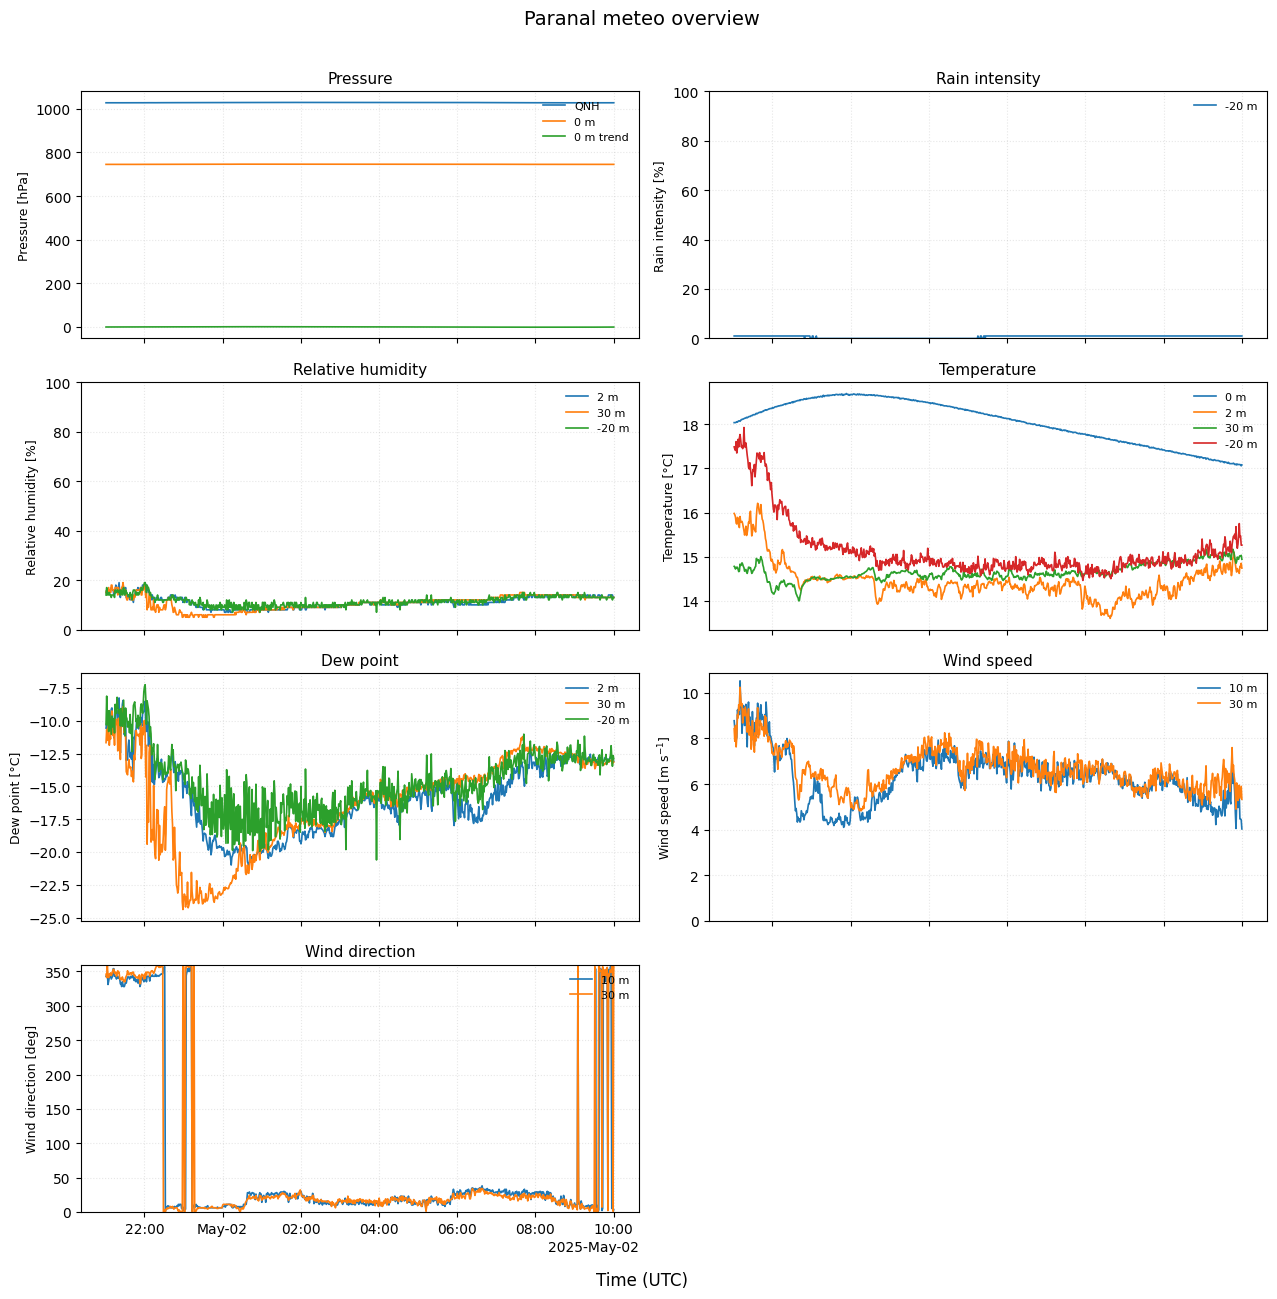

In [5]:
# Grouped meteo overview: measurements grouped on common axes (no mean trend)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time

# Time axis
time_col = "midpoint_date" if "midpoint_date" in table.colnames else "start_date"
t = Time(np.array(table[time_col].data.data, dtype="datetime64"))
x_full = t.plot_date

# Downsample for performance
MAX_POINTS = 5000
n = len(x_full)
if n > MAX_POINTS:
    idx = np.linspace(0, n - 1, MAX_POINTS).astype(int)
else:
    idx = slice(None)

x = x_full[idx]

def to_float(name):
    if name not in table.colnames:
        return None
    y = np.asarray(table[name][idx])
    if np.ma.isMaskedArray(y):
        y = np.ma.filled(y, np.nan)
    return np.asarray(y, dtype=float)

def plot_group(ax, series, title, ylabel, ylim=None):
    for col, lab in series:
        y = to_float(col)
        if y is None:
            continue
        ax.plot(x, y, lw=1.2, label=lab)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.3, ls=":")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(frameon=False, fontsize=8, loc="upper right")

groups = []

pressure_series = []
for col, lab in [("presqnh", "QNH"), ("press_0m", "0 m"), ("prestrend_0m", "0 m trend")]:
    if col in table.colnames:
        pressure_series.append((col, lab))
if pressure_series:
    groups.append(("Pressure", pressure_series, "Pressure [hPa]", None))

rain_series = []
for col, lab in [("rain_m20m", "-20 m")]:
    if col in table.colnames:
        rain_series.append((col, lab))
if rain_series:
    groups.append(("Rain intensity", rain_series, "Rain intensity [%]", (0, 100)))

rhum_series = []
for col, lab in [("rhum_2m", "2 m"), ("rhum_30m", "30 m"), ("rhum_m20m", "-20 m")]:
    if col in table.colnames:
        rhum_series.append((col, lab))
if rhum_series:
    groups.append(("Relative humidity", rhum_series, "Relative humidity [%]", (0, 100)))

temp_series = []
for col, lab in [("temp_0m", "0 m"), ("temp_2m", "2 m"), ("temp_30m", "30 m"), ("temp_m20m", "-20 m")]:
    if col in table.colnames:
        temp_series.append((col, lab))
if temp_series:
    groups.append(("Temperature", temp_series, "Temperature [°C]", None))

dew_series = []
for col, lab in [("tempdew_2m", "2 m"), ("tempdew_30m", "30 m"), ("tempdew_m20m", "-20 m")]:
    if col in table.colnames:
        dew_series.append((col, lab))
if dew_series:
    groups.append(("Dew point", dew_series, "Dew point [°C]", None))

ws_series = []
for col, lab in [("wind_speed_10m", "10 m"), ("wind_speed_30m", "30 m")]:
    if col in table.colnames:
        ws_series.append((col, lab))
if ws_series:
    groups.append(("Wind speed", ws_series, "Wind speed [m s$^{-1}$]", (0, None)))

wd_series = []
for col, lab in [("wind_dir_10m", "10 m"), ("wind_dir_30m", "30 m")]:
    if col in table.colnames:
        wd_series.append((col, lab))
if wd_series:
    groups.append(("Wind direction", wd_series, "Wind direction [deg]", (0, 360)))

n_panels = len(groups)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6.4 * ncols, 3.2 * nrows), sharex=True)
axes = np.ravel(axes)

for i, (title, series, ylabel, ylim) in enumerate(groups):
    plot_group(axes[i], series, title, ylabel, ylim)

for ax in axes[n_panels:]:
    ax.axis("off")

locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)
for ax in axes[:n_panels]:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

fig.suptitle("Paranal meteo overview", fontsize=14, y=1.01)
fig.supxlabel("Time (UTC)")
fig.tight_layout()
plt.show()